### Import Library

In [3]:
# Install TensorFlow
!pip install tensorflow

# Import modul standar Python
import os                # Untuk navigasi folder dan file
import zipfile           # Untuk mengekstrak file ZIP
import random            # Untuk mengacak data (misalnya saat split train/val)
import numpy as np       # Untuk manipulasi data array
import matplotlib.pyplot as plt  # Untuk membuat grafik visual (akurasi, loss, dsb)
import seaborn as sns    # Untuk visualisasi heatmap, confusion matrix, dll

# Import TensorFlow dan modul deep learning dari Keras
import tensorflow as tf  # Library utama deep learning
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# => Untuk preprocessing & augmentasi gambar otomatis

from tensorflow.keras.models import Sequential
# => Untuk membuat model layer bertahap (CNN dasar)

from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
# => Layer-layer inti dalam CNN:
#    - Conv2D: Layer konvolusi untuk ekstraksi fitur gambar
#    - MaxPooling2D: Layer reduksi dimensi (downsampling)
#    - Flatten: Mengubah output menjadi 1D sebelum fully connected layer
#    - Dense: Layer fully connected
#    - Dropout: Mencegah overfitting
#    - BatchNormalization: Menstabilkan dan mempercepat training

from tensorflow.keras.optimizers import Adam
# => Optimizer yang populer dan efisien untuk update bobot

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
# => Callback penting:
#    - EarlyStopping: Menghentikan training lebih awal jika tidak ada peningkatan
#    - ModelCheckpoint: Menyimpan model terbaik selama training
#    - ReduceLROnPlateau: Menurunkan learning rate jika training stagnan

# Import fungsi evaluasi dari sklearn
from sklearn.metrics import classification_report, confusion_matrix
# => Digunakan untuk mengevaluasi performa model dengan metrik seperti precision, recall, F1, dan confusion matrix


### Import dataset

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/Colab Notebooks/Capsstone/Dataset.zip'
extract_to = '/content/plantvillage'

# Ekstrak zip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

# Cek isi folder hasil ekstraksi
print("Daftar folder kelas:")
print(os.listdir(extract_to))

Daftar folder kelas:
['plantvillage', 'PlantVillage']


In [6]:
# Cek isi folder 'plantvillage'
print("Isi 'plantvillage':")
print(os.listdir('/content/plantvillage/plantvillage'))

# Cek isi folder 'PlantVillage'
print("\nIsi 'PlantVillage':")
print(os.listdir('/content/plantvillage/PlantVillage'))

Isi 'plantvillage':
['PlantVillage']

Isi 'PlantVillage':
['Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_Late_blight', 'Tomato_healthy', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_Leaf_Mold', 'Pepper__bell___healthy', 'Tomato_Septoria_leaf_spot', 'Tomato__Target_Spot', 'Tomato_Early_blight', 'Tomato_Bacterial_spot', 'Tomato__Tomato_mosaic_virus', 'Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight', 'Pepper__bell___Bacterial_spot']


### Setup Preprocessing dan augmentasi data

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Inisialisasi ImageDataGenerator untuk training dan validasi
train_datagen = ImageDataGenerator(
    rescale=1./255,                # Normalisasi pixel 0-255 menjadi 0-1
    validation_split=0.2,          # Bagi 20% data sebagai validasi
    rotation_range=15,             # Augmentasi: rotasi gambar
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

## Generate data dan output

In [8]:
img_size = (150, 150)
batch_size = 32
data_dir = '/content/plantvillage/PlantVillage'

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# Output jumlah kelas dan contohnya
class_names = list(train_generator.class_indices.keys())
print(f"✅ Jumlah kelas: {len(class_names)}")
print(f"🎨 Nama kelas (contoh 10 pertama):\n{class_names[:10]}")


Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.
✅ Jumlah kelas: 15
🎨 Nama kelas (contoh 10 pertama):
['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot']


## Visuaisasi contoh gambar dari data set

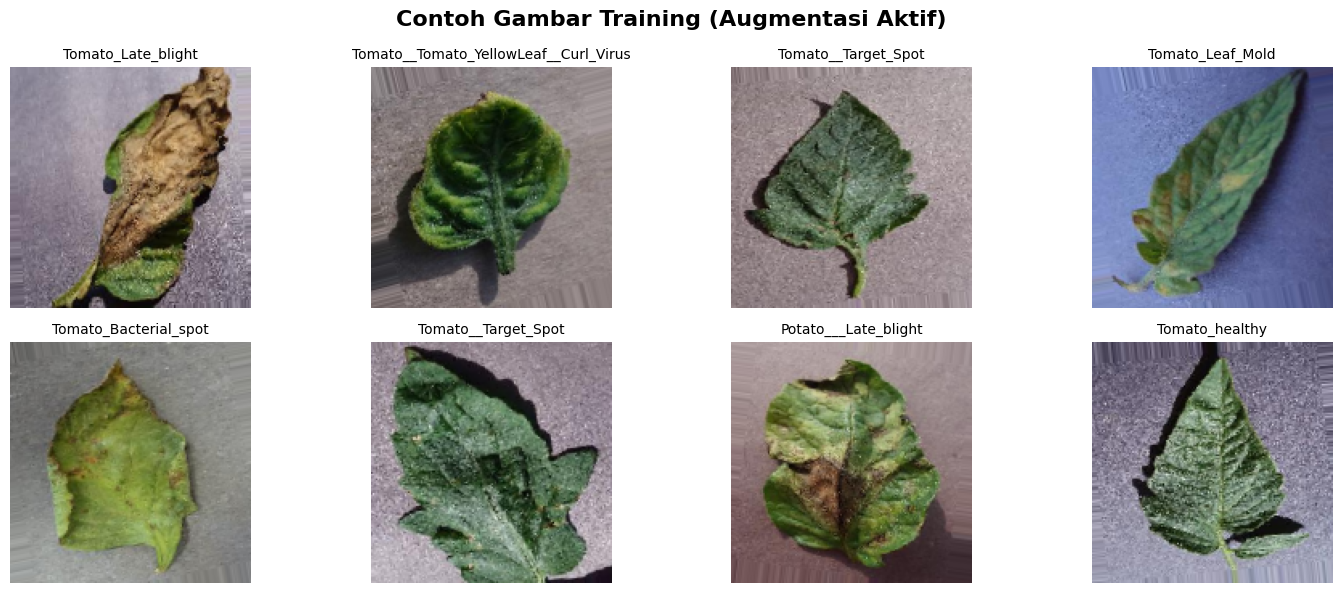

In [9]:
# Tampilkan 8 gambar pertama dari training set
import matplotlib.pyplot as plt

sample_images, sample_labels = next(train_generator)

plt.figure(figsize=(15, 6))
plt.suptitle("Contoh Gambar Training (Augmentasi Aktif)", fontsize=16, fontweight='bold')

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(sample_images[i])
    label_index = sample_labels[i].argmax()
    label = class_names[label_index]
    plt.title(label, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()


/tmp/ipython-input-10-3537840863.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_counts.sort_values("Jumlah", ascending=False), x='Jumlah', y='Kelas', palette='viridis')


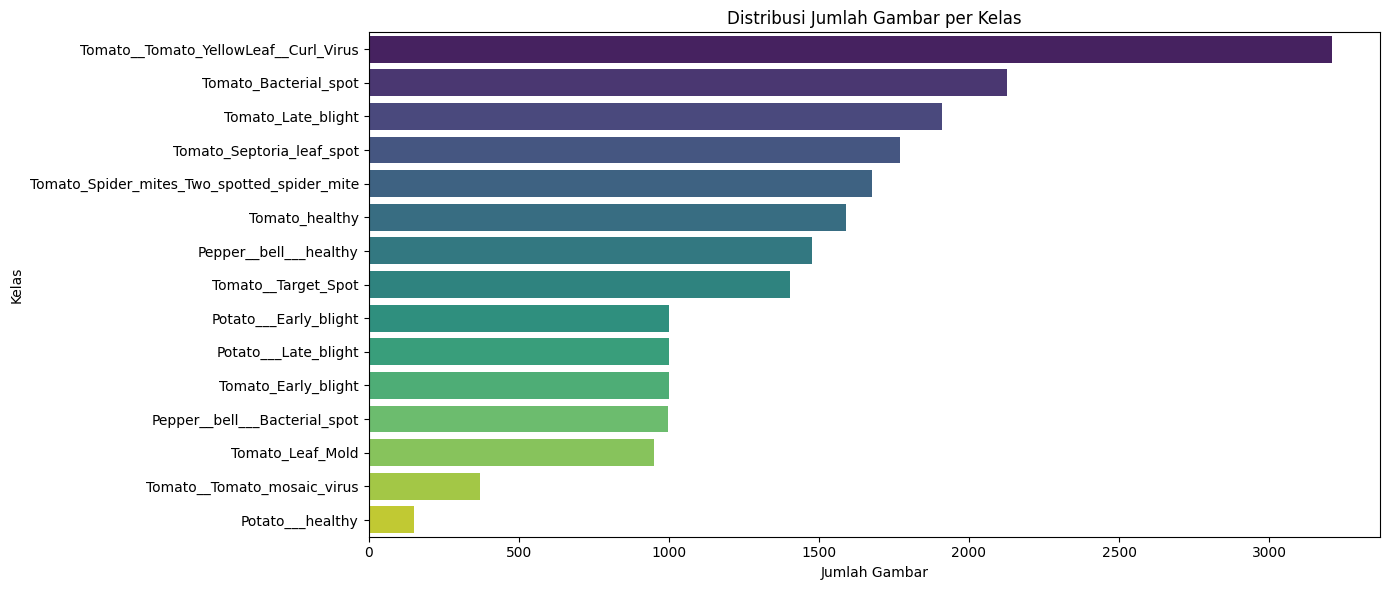

In [10]:
import pandas as pd
import seaborn as sns

# Hitung jumlah gambar per kelas
folder_counts = {k: len(os.listdir(os.path.join(data_dir, k))) for k in class_names}
df_counts = pd.DataFrame(folder_counts.items(), columns=['Kelas', 'Jumlah'])

plt.figure(figsize=(14, 6))
sns.barplot(data=df_counts.sort_values("Jumlah", ascending=False), x='Jumlah', y='Kelas', palette='viridis')
plt.title('Distribusi Jumlah Gambar per Kelas')
plt.xlabel('Jumlah Gambar')
plt.ylabel('Kelas')
plt.tight_layout()
plt.show()


### CNN dan Training Model

## Membuat arsitektur CNN

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

# Jumlah kelas berdasarkan generator
num_classes = len(train_generator.class_indices)

# Membangun model CNN
model = Sequential([
    # Blok 1
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Blok 2
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Blok 3
    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # FC layer
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')  # Softmax untuk multiclass
])

# Kompilasi model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',  # karena multiclass
    metrics=['accuracy']
)

# Tampilkan ringkasan arsitektur
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,470,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,568,207 (36.50 MB)

 Trainable params: 9,567,759 (36.50 MB)

 Non-trainable params: 448 (1.75 KB)

## Callback adn Training model

In [12]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Setup callback
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_plant_model.h5', save_best_only=True, monitor='val_accuracy', mode='max')
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)

# Latih model
history = model.fit(
    train_generator,
    epochs=25,
    validation_data=val_generator,
    callbacks=[early_stop, checkpoint, reduce_lr]
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.2761 - loss: 3.4756

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


517/517 ━━━━━━━━━━━━━━━━━━━━ 123s 220ms/step - accuracy: 0.2762 - loss: 3.4736 - val_accuracy: 0.5005 - val_loss: 1.6261 - learning_rate: 0.0010
Epoch 2/25
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.4015 - loss: 1.9572

517/517 ━━━━━━━━━━━━━━━━━━━━ 128s 206ms/step - accuracy: 0.4015 - loss: 1.9570 - val_accuracy: 0.5551 - val_loss: 1.8211 - learning_rate: 0.0010
Epoch 3/25
517/517 ━━━━━━━━━━━━━━━━━━━━ 142s 206ms/step - accuracy: 0.4720 - loss: 1.6806 - val_accuracy: 0.4403 - val_loss: 2.9495 - learning_rate: 0.0010
Epoch 4/25
517/517 ━━━━━━━━━━━━━━━━━━━━ 105s 204ms/step - accuracy: 0.4978 - loss: 1.5916 - val_accuracy: 0.3937 - val_loss: 2.6787 - learning_rate: 0.0010
Epoch 5/25
517/517 ━━━━━━━━━━━━━━━━━━━━ 105s 203ms/step - accuracy: 0.5538 - loss: 1.3499 - val_accuracy: 0.5053 - val_loss: 3.0958 - learning_rate: 2.0000e-04
Epoch 6/25
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.6028 - loss: 1.2080

517/517 ━━━━━━━━━━━━━━━━━━━━ 106s 205ms/step - accuracy: 0.6028 - loss: 1.2080 - val_accuracy: 0.6955 - val_loss: 1.0776 - learning_rate: 2.0000e-04
Epoch 7/25
517/517 ━━━━━━━━━━━━━━━━━━━━ 110s 213ms/step - accuracy: 0.6002 - loss: 1.1886 - val_accuracy: 0.5403 - val_loss: 3.0827 - learning_rate: 2.0000e-04
Epoch 8/25
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.6148 - loss: 1.1337

517/517 ━━━━━━━━━━━━━━━━━━━━ 106s 204ms/step - accuracy: 0.6148 - loss: 1.1336 - val_accuracy: 0.7018 - val_loss: 1.2790 - learning_rate: 2.0000e-04
Epoch 9/25
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.6391 - loss: 1.0657

517/517 ━━━━━━━━━━━━━━━━━━━━ 106s 205ms/step - accuracy: 0.6391 - loss: 1.0657 - val_accuracy: 0.7688 - val_loss: 0.7436 - learning_rate: 2.0000e-04
Epoch 10/25
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.6522 - loss: 1.0147

517/517 ━━━━━━━━━━━━━━━━━━━━ 142s 204ms/step - accuracy: 0.6522 - loss: 1.0147 - val_accuracy: 0.7690 - val_loss: 0.9127 - learning_rate: 2.0000e-04
Epoch 11/25
517/517 ━━━━━━━━━━━━━━━━━━━━ 105s 203ms/step - accuracy: 0.6658 - loss: 0.9807 - val_accuracy: 0.6521 - val_loss: 2.6248 - learning_rate: 2.0000e-04
Epoch 12/25
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.7017 - loss: 0.8894

517/517 ━━━━━━━━━━━━━━━━━━━━ 105s 203ms/step - accuracy: 0.7017 - loss: 0.8894 - val_accuracy: 0.8006 - val_loss: 0.7254 - learning_rate: 2.0000e-04
Epoch 13/25
517/517 ━━━━━━━━━━━━━━━━━━━━ 110s 212ms/step - accuracy: 0.7128 - loss: 0.8354 - val_accuracy: 0.6912 - val_loss: 2.0831 - learning_rate: 2.0000e-04
Epoch 14/25
517/517 ━━━━━━━━━━━━━━━━━━━━ 105s 202ms/step - accuracy: 0.7249 - loss: 0.8250 - val_accuracy: 0.7683 - val_loss: 1.4222 - learning_rate: 2.0000e-04
Epoch 15/25
517/517 ━━━━━━━━━━━━━━━━━━━━ 105s 202ms/step - accuracy: 0.7422 - loss: 0.7755 - val_accuracy: 0.7382 - val_loss: 1.4226 - learning_rate: 2.0000e-04
Epoch 16/25
517/517 ━━━━━━━━━━━━━━━━━━━━ 106s 204ms/step - accuracy: 0.7560 - loss: 0.7124 - val_accuracy: 0.7492 - val_loss: 1.8425 - learning_rate: 4.0000e-05
Epoch 17/25
517/517 ━━━━━━━━━━━━━━━━━━━━ 105s 202ms/step - accuracy: 0.7731 - loss: 0.6650 - val_accuracy: 0.7535 - val_loss: 1.5918 - learning_rate: 4.0000e-05


### **Swicth metode menggunakan MobileNetV2**

In [13]:
num_classes = len(train_generator.class_indices)


### Arsitektur MobileNetV2

In [14]:
# 📦 Import library MobileNetV2 dan layer tambahan
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense

# ✅ Load base MobileNetV2 tanpa classifier (include_top=False)
base_model = MobileNetV2(
    include_top=False,
    weights='imagenet',
    input_shape=(150, 150, 3)
)

# ❄️ Bekukan semua layer MobileNetV2 untuk training awal
base_model.trainable = False

# 🔧 Tambahkan classification head kita sendiri di atas base model
x = base_model.output
x = GlobalAveragePooling2D()(x)       # Rata-rata semua fitur spatial
x = Dropout(0.3)(x)                    # Dropout agar tidak overfitting
predictions = Dense(num_classes, activation='softmax')(x)  # Output = jumlah kelas

# ⚙️ Buat model akhir (gabungan base + head)
model = Model(inputs=base_model.input, outputs=predictions)

# 🧠 Kompilasi model dengan Adam optimizer dan categorical loss
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 📋 Ringkasan model
model.summary()


/tmp/ipython-input-14-217106777.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 75, 75,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 75, 75,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 75, 75,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 75, 75,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 75, 75,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 75, 75,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 77, 77,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 38, 38,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 38, 38,    │      2,304 │ block_1_depthwis

 Total params: 2,277,199 (8.69 MB)

 Trainable params: 19,215 (75.06 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Training Awal

In [20]:
# 🚀 Latih hanya bagian head (custom classifier)
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop, checkpoint, reduce_lr]
)


Epoch 1/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 109s 210ms/step - accuracy: 0.8544 - loss: 0.4304 - val_accuracy: 0.8535 - val_loss: 0.4333 - learning_rate: 0.0010
Epoch 2/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 140s 207ms/step - accuracy: 0.8578 - loss: 0.4145 - val_accuracy: 0.8537 - val_loss: 0.4431 - learning_rate: 0.0010
Epoch 3/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 106s 204ms/step - accuracy: 0.8595 - loss: 0.4129 - val_accuracy: 0.8649 - val_loss: 0.4142 - learning_rate: 0.0010
Epoch 4/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 104s 202ms/step - accuracy: 0.8563 - loss: 0.4213 - val_accuracy: 0.8472 - val_loss: 0.4710 - learning_rate: 0.0010
Epoch 5/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 107s 207ms/step - accuracy: 0.8620 - loss: 0.4069 - val_accuracy: 0.8629 - val_loss: 0.4179 - learning_rate: 0.0010
Epoch 6/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.8653 - loss: 0.4067

517/517 ━━━━━━━━━━━━━━━━━━━━ 119s 231ms/step - accuracy: 0.8653 - loss: 0.4067 - val_accuracy: 0.8697 - val_loss: 0.4043 - learning_rate: 0.0010
Epoch 7/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.8610 - loss: 0.4068

517/517 ━━━━━━━━━━━━━━━━━━━━ 106s 205ms/step - accuracy: 0.8610 - loss: 0.4069 - val_accuracy: 0.8705 - val_loss: 0.3990 - learning_rate: 0.0010
Epoch 8/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 106s 205ms/step - accuracy: 0.8695 - loss: 0.3813 - val_accuracy: 0.8700 - val_loss: 0.4100 - learning_rate: 0.0010
Epoch 9/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.8650 - loss: 0.4196

517/517 ━━━━━━━━━━━━━━━━━━━━ 149s 219ms/step - accuracy: 0.8650 - loss: 0.4196 - val_accuracy: 0.8736 - val_loss: 0.3909 - learning_rate: 0.0010
Epoch 10/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 144s 223ms/step - accuracy: 0.8653 - loss: 0.4124 - val_accuracy: 0.8680 - val_loss: 0.4118 - learning_rate: 0.0010


## Visualisasi Akurasi dan loss training

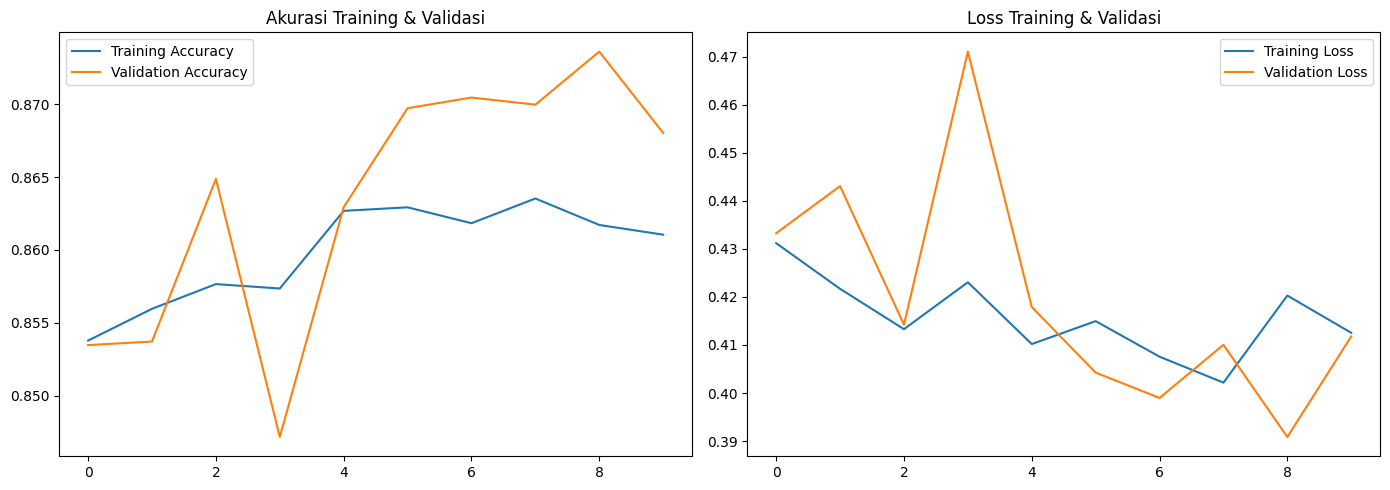

In [21]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

# 📊 Akurasi
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Akurasi Training & Validasi')
plt.legend()

# 📉 Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Loss Training & Validasi')
plt.legend()

plt.tight_layout()
plt.show()


## Fine tuning (unfreeze sebagian ayer mobienetV2)

In [22]:
# ✅ Buka sebagian layer (misal setelah ke-100)
base_model.trainable = True
fine_tune_at = 100

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# 🔁 Kompilasi ulang model dengan learning rate lebih kecil
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 🚀 Lanjutkan training dengan fine-tune seluruh model
history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop, checkpoint, reduce_lr]
)


Epoch 1/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 146s 241ms/step - accuracy: 0.5448 - loss: 2.6410 - val_accuracy: 0.8581 - val_loss: 0.5000 - learning_rate: 1.0000e-05
Epoch 2/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 106s 206ms/step - accuracy: 0.7657 - loss: 0.7775 - val_accuracy: 0.8508 - val_loss: 0.5319 - learning_rate: 1.0000e-05
Epoch 3/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 142s 206ms/step - accuracy: 0.8103 - loss: 0.5848 - val_accuracy: 0.8639 - val_loss: 0.4664 - learning_rate: 1.0000e-05
Epoch 4/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.8380 - loss: 0.4744

517/517 ━━━━━━━━━━━━━━━━━━━━ 111s 215ms/step - accuracy: 0.8380 - loss: 0.4744 - val_accuracy: 0.8768 - val_loss: 0.4232 - learning_rate: 1.0000e-05
Epoch 5/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.8587 - loss: 0.4173

517/517 ━━━━━━━━━━━━━━━━━━━━ 107s 207ms/step - accuracy: 0.8587 - loss: 0.4172 - val_accuracy: 0.8867 - val_loss: 0.3565 - learning_rate: 1.0000e-05
Epoch 6/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.8801 - loss: 0.3491

517/517 ━━━━━━━━━━━━━━━━━━━━ 107s 207ms/step - accuracy: 0.8801 - loss: 0.3491 - val_accuracy: 0.9005 - val_loss: 0.3208 - learning_rate: 1.0000e-05
Epoch 7/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.8898 - loss: 0.3182

517/517 ━━━━━━━━━━━━━━━━━━━━ 107s 208ms/step - accuracy: 0.8898 - loss: 0.3182 - val_accuracy: 0.9049 - val_loss: 0.3028 - learning_rate: 1.0000e-05
Epoch 8/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.8975 - loss: 0.2953

517/517 ━━━━━━━━━━━━━━━━━━━━ 107s 208ms/step - accuracy: 0.8975 - loss: 0.2952 - val_accuracy: 0.9102 - val_loss: 0.2856 - learning_rate: 1.0000e-05
Epoch 9/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.9143 - loss: 0.2560

517/517 ━━━━━━━━━━━━━━━━━━━━ 107s 207ms/step - accuracy: 0.9143 - loss: 0.2560 - val_accuracy: 0.9216 - val_loss: 0.2545 - learning_rate: 1.0000e-05
Epoch 10/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 0.9170 - loss: 0.2365

517/517 ━━━━━━━━━━━━━━━━━━━━ 106s 206ms/step - accuracy: 0.9170 - loss: 0.2365 - val_accuracy: 0.9236 - val_loss: 0.2447 - learning_rate: 1.0000e-05


## Visuaisasi Fine Tuning (epoch tambahan)

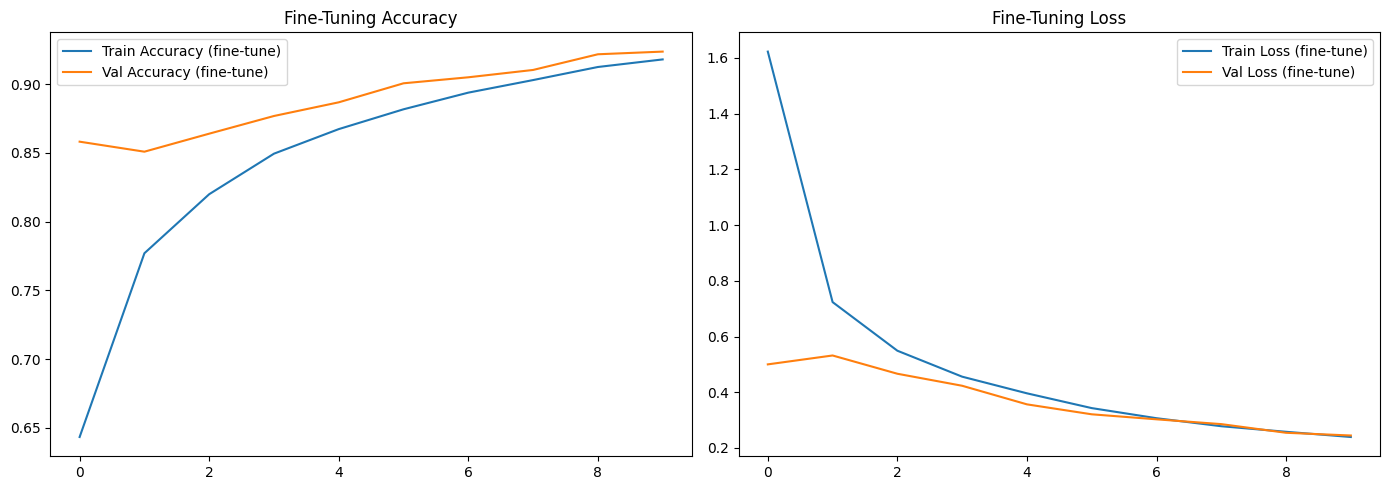

In [23]:
# Ambil history tambahan
acc_ft = history_finetune.history['accuracy']
val_acc_ft = history_finetune.history['val_accuracy']
loss_ft = history_finetune.history['loss']
val_loss_ft = history_finetune.history['val_loss']

epochs_range_ft = range(len(acc_ft))

plt.figure(figsize=(14, 5))

# 📊 Akurasi fine-tuning
plt.subplot(1, 2, 1)
plt.plot(epochs_range_ft, acc_ft, label='Train Accuracy (fine-tune)')
plt.plot(epochs_range_ft, val_acc_ft, label='Val Accuracy (fine-tune)')
plt.title('Fine-Tuning Accuracy')
plt.legend()

# 📉 Loss fine-tuning
plt.subplot(1, 2, 2)
plt.plot(epochs_range_ft, loss_ft, label='Train Loss (fine-tune)')
plt.plot(epochs_range_ft, val_loss_ft, label='Val Loss (fine-tune)')
plt.title('Fine-Tuning Loss')
plt.legend()

plt.tight_layout()
plt.show()


### Evaluasi Model

In [24]:
# 🔄 Reset generator agar prediksi dimulai dari awal
val_generator.reset()

# 🔮 Prediksi probabilitas semua gambar validasi
pred_probs = model.predict(val_generator)

# 🔢 Ubah dari probabilitas ke label kelas (argmax)
pred_classes = np.argmax(pred_probs, axis=1)

# 🏷️ Label sebenarnya
true_classes = val_generator.classes

# 🔠 Daftar nama kelas
class_labels = list(val_generator.class_indices.keys())


129/129 ━━━━━━━━━━━━━━━━━━━━ 11s 57ms/step


## Classification Report

In [25]:
from sklearn.metrics import classification_report

print("📋 Classification Report:\n")
print(classification_report(true_classes, pred_classes, target_names=class_labels))


📋 Classification Report:

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.93      0.98      0.96       199
                     Pepper__bell___healthy       0.97      0.99      0.98       295
                      Potato___Early_blight       0.97      0.96      0.97       200
                       Potato___Late_blight       0.96      0.96      0.96       200
                           Potato___healthy       0.97      0.93      0.95        30
                      Tomato_Bacterial_spot       0.93      0.96      0.94       425
                        Tomato_Early_blight       0.94      0.59      0.73       200
                         Tomato_Late_blight       0.92      0.91      0.91       381
                           Tomato_Leaf_Mold       0.97      0.89      0.93       190
                  Tomato_Septoria_leaf_spot       0.83      0.93      0.88       354
Tomato_Spider_mites_Two_spotted_spider

## Confussion matriks

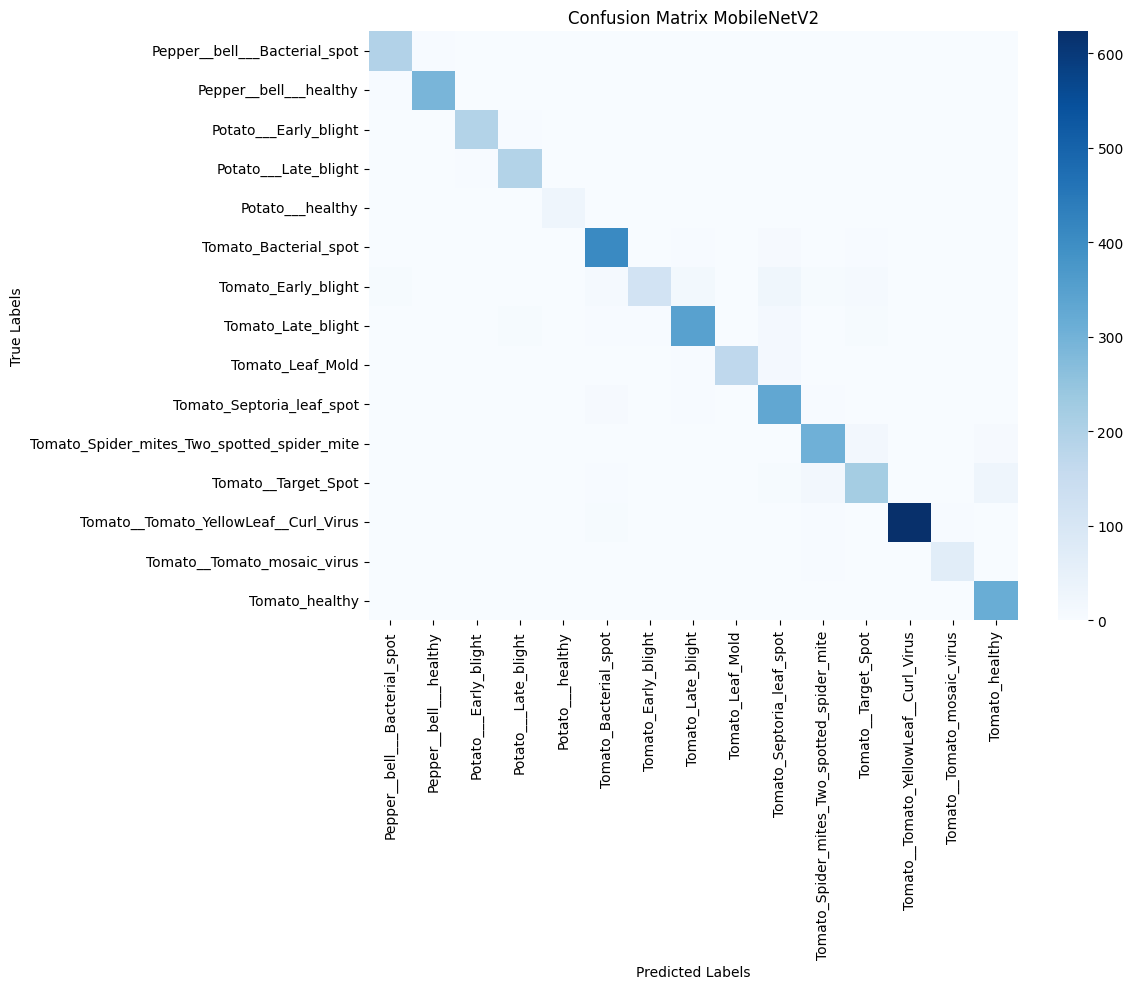

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Buat confusion matrix
cm = confusion_matrix(true_classes, pred_classes)

# Visualisasi dengan heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.title('Confusion Matrix MobileNetV2')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.tight_layout()
plt.show()


## Visualisasi prediksi gambar validasi

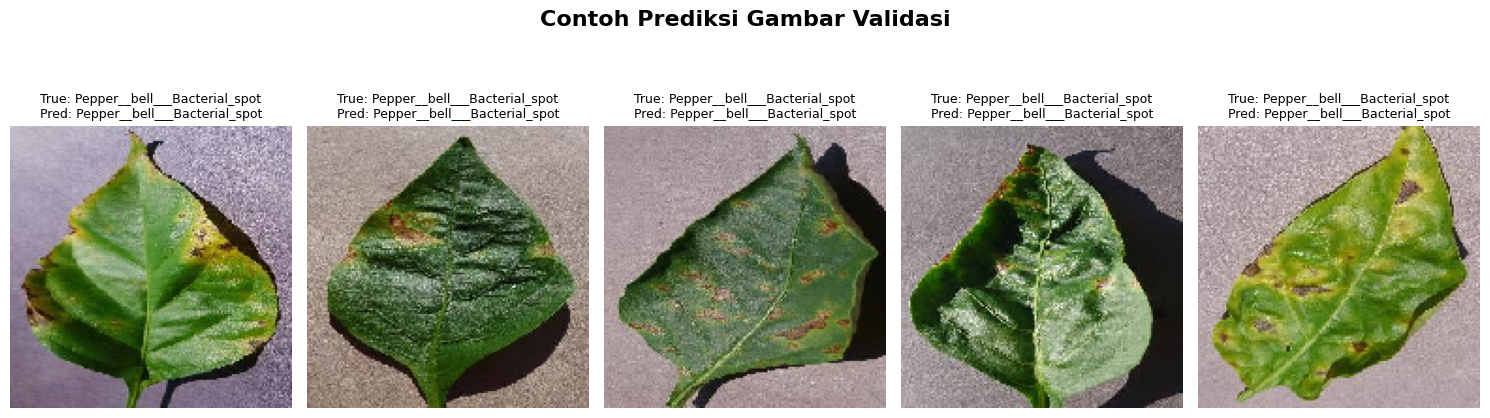

In [27]:
import random

# Ambil batch gambar dan label
images, labels = next(val_generator)

# Tampilkan 5 gambar validasi dan prediksinya
plt.figure(figsize=(15, 5))
plt.suptitle("Contoh Prediksi Gambar Validasi", fontsize=16, fontweight='bold')

for i in range(5):
    idx = random.randint(0, len(images) - 1)
    image = images[idx]
    true_label = class_labels[np.argmax(labels[idx])]
    pred_label = class_labels[np.argmax(pred_probs[idx])]

    plt.subplot(1, 5, i+1)
    plt.imshow(image)
    plt.title(f"True: {true_label}\nPred: {pred_label}", fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()


### Uji gambar dari luar

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


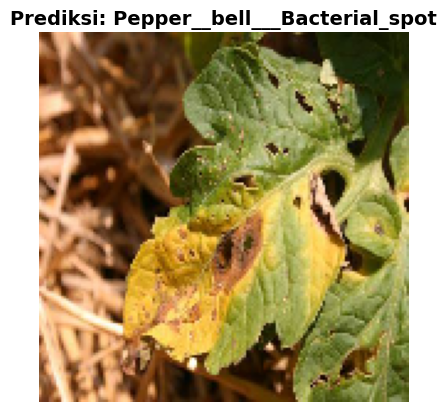

In [28]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# 🔍 Path file gambar
img_path = '/content/drive/MyDrive/Colab Notebooks/Capsstone/tomato early blight.jpeg'  # ganti sesuai nama file yang kamu upload

# 📏 Preprocessing gambar agar sesuai input model
img = image.load_img(img_path, target_size=(150, 150))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)     # tambahkan batch dimensi
img_array = img_array / 255.0                      # normalisasi

# 🔮 Prediksi kelas
pred_prob = model.predict(img_array)
pred_class_index = np.argmax(pred_prob)
pred_class = class_labels[pred_class_index]

# 🎨 Tampilkan hasil
plt.imshow(img)
plt.title(f"Prediksi: {pred_class}", fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()


### Instal dan Import Gradio

In [29]:
!pip install gradio
import gradio as gr
from tensorflow.keras.preprocessing import image
import numpy as np

## Definisi fungsi prediksi gradio

In [30]:
def prediksi_daun(img):
    # Resize & normalisasi gambar
    img = img.resize((150, 150))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # Prediksi kelas
    pred = model.predict(img_array)
    pred_index = np.argmax(pred)
    pred_label = class_labels[pred_index]

    return f"Prediksi: {pred_label}"


### Buat UI web

In [31]:
# Buat antarmuka input gambar
gr.Interface(
    fn=prediksi_daun,                       # Fungsi utama
    inputs=gr.Image(type="pil", label="Upload Gambar Daun"),
    outputs="text",
    title="📸 Klasifikasi Penyakit Daun - PlantVillage CNN",
    description="Upload gambar daun, dan model akan memprediksi jenis penyakitnya.",
    examples=None
).launch()


It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://248201c537188cc336.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
